In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from src.utils.transformation_utils import CoordTransformer

In [2]:
root_result_dir = "./results"

In [3]:
def load_data_for_sequence(seq):
    result_dir = os.path.join(root_result_dir, seq)
    dead_reckoning = np.load(os.path.join(result_dir, "dead_reckoning.npz"))
    ml_enhanced_dead_reckoning = np.load(os.path.join(result_dir, "ml_enhanced_dead_reckoning.npz"))
    map_aided_ml_enhanced_dead_reckoning = np.load(os.path.join(result_dir, "map_aided_ml_enhanced_dead_reckoning.npz"))

    lla = ml_enhanced_dead_reckoning["lla_ground_truth"]
    transform = CoordTransformer()
    for i in range(lla.shape[0]):
        pos = transform.transform(np.array([lla[i, 0], lla[i, 1], lla[i, 2]]))


    edges_map = gpd.read_parquet(f'./data/KITTI/raw/karlsruhe_edges.parquet')
    min_lon, min_lat, _ = np.min(lla, axis=0)
    max_lon, max_lat, _ = np.max(lla, axis=0)
    local_edges = edges_map.cx[min_lon:max_lon, min_lat:max_lat]

    return dead_reckoning, ml_enhanced_dead_reckoning, map_aided_ml_enhanced_dead_reckoning, local_edges, transform

def load_ai_imu_data_for_sequence(seq, transformer: CoordTransformer):
    result_dir = os.path.join(root_result_dir, seq)
    ai_imu_data = np.load(os.path.join(result_dir, "ai_imu_dead_reckoning.npz"))
    estimated_trajectory = ai_imu_data["estimated_trajectory"]
    pos_in_lla = []
    for pos in estimated_trajectory:
        lla = transformer.transform_to_lla(np.array([pos[0], pos[1], pos[2]]))
        pos_in_lla.append(lla)

    data = dict()
    for key, value in ai_imu_data.items():
        if key == "estimated_angle":
            key = "estimated_orientation"
        elif key == "ground_truth_angle":
            key = "ground_truth_orientation"
        data[key] = value
    data["lla_estimated"] = np.array(pos_in_lla)
    return data


def visualize_trajectories(
    seq,
    dead_reckoning,
    ml_enhanced_dead_reckoning,
    map_aided_ml_enhanced_dead_reckoning,
    ai_imu_dead_reckoning=None,
    local_edges=None,
    loc="lower left",
):
    ai_imu_predicted = None
    if local_edges is not None:
        dr_predicted = dead_reckoning["lla_estimated"]
        ml_dr_predicted = ml_enhanced_dead_reckoning["lla_estimated"]
        map_aided_ml_dr_predicted = map_aided_ml_enhanced_dead_reckoning["lla_estimated"]
        ground_truth = ml_enhanced_dead_reckoning["lla_ground_truth"]
        if ai_imu_dead_reckoning is not None:
            ai_imu_predicted = ai_imu_dead_reckoning["lla_estimated"]
        xlabel = "Longitude"
        ylabel = "Latitude"
    else:
        dr_predicted = dead_reckoning["estimated_trajectory"]
        ml_dr_predicted = ml_enhanced_dead_reckoning["estimated_trajectory"]
        map_aided_ml_dr_predicted = map_aided_ml_enhanced_dead_reckoning["estimated_trajectory"]
        ground_truth = ml_enhanced_dead_reckoning["ground_truth_trajectory"]
        if ai_imu_dead_reckoning is not None:
            ai_imu_predicted = ai_imu_dead_reckoning["estimated_trajectory"]
        xlabel = "X Position (m)"
        ylabel = "Y Position (m)"
    
    plt.figure(figsize=(10, 6))
    if local_edges is not None:
        local_edges.plot(ax=plt.gca(), color="gray", linestyle="-.", linewidth=0.5, label="OSM Edges")
    plt.plot(ground_truth[:, 0], ground_truth[:, 1], label="Ground Truth", color="black", linewidth=2)
    plt.plot(dr_predicted[:, 0], dr_predicted[:, 1], label="Dead Reckoning", color="green")
    plt.plot(ml_dr_predicted[:, 0], ml_dr_predicted[:, 1], label="ML-Enhanced Dead Reckoning", color="orange")
    plt.plot(map_aided_ml_dr_predicted[:, 0], map_aided_ml_dr_predicted[:, 1], label="Map-Aided ML-Enhanced Dead Reckoning", lw=2)
    if ai_imu_predicted is not None:
        plt.plot(ai_imu_predicted[:, 0], ai_imu_predicted[:, 1], label="AI-IMU Dead Reckoning", color="red")
    plt.legend(loc=loc)    
    plt.title(f"Trajectory Comparison for Sequence {seq}")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.axis("equal")
    plt.grid()
    plt.show()

## Sequence 09

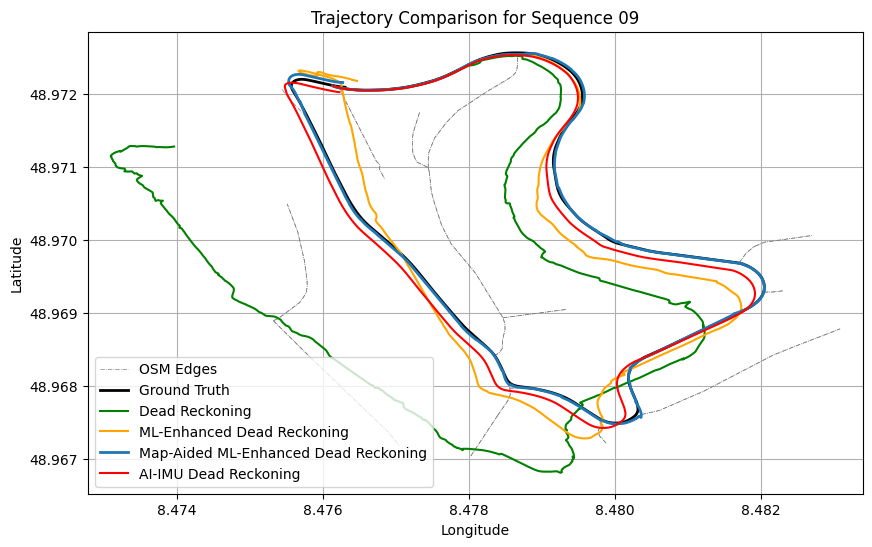

In [4]:
dead_reckoning_09, ml_enhanced_dead_reckoning_09, map_aided_ml_enhanced_dead_reckoning_09, local_edges_09, transformer_09 = load_data_for_sequence(seq="09")
ai_imu_dead_reckoning_09 = load_ai_imu_data_for_sequence(seq="09", transformer=transformer_09)
visualize_trajectories(
    "09",
    dead_reckoning_09,
    ml_enhanced_dead_reckoning_09,
    map_aided_ml_enhanced_dead_reckoning_09,
    ai_imu_dead_reckoning_09,
    local_edges_09,
)

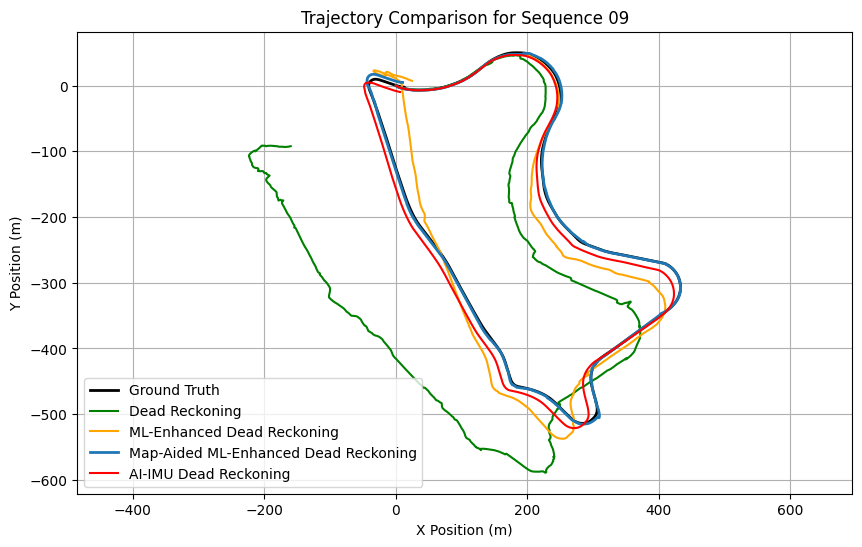

In [5]:
visualize_trajectories(
    "09",
    dead_reckoning_09,
    ml_enhanced_dead_reckoning_09,
    map_aided_ml_enhanced_dead_reckoning_09,
    ai_imu_dead_reckoning_09,
)

## Sequence 10

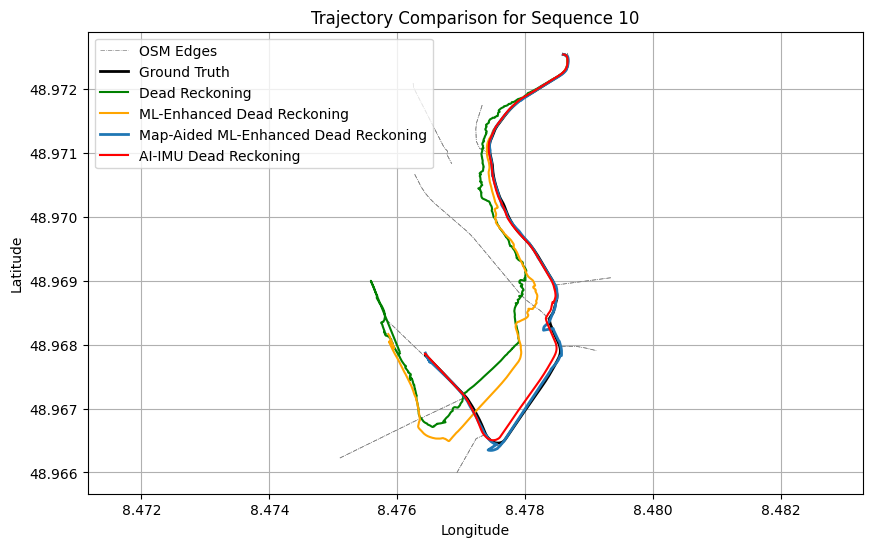

In [6]:
dead_reckoning_10, ml_enhanced_dead_reckoning_10, map_aided_ml_enhanced_dead_reckoning_10, local_edges_10, transformer_10 = load_data_for_sequence(seq="10")
ai_imu_dead_reckoning_10 = load_ai_imu_data_for_sequence(seq="10", transformer=transformer_10)
visualize_trajectories(
    "10",
    dead_reckoning_10,
    ml_enhanced_dead_reckoning_10,
    map_aided_ml_enhanced_dead_reckoning_10,
    ai_imu_dead_reckoning_10,
    local_edges_10,
    loc="upper left",
)

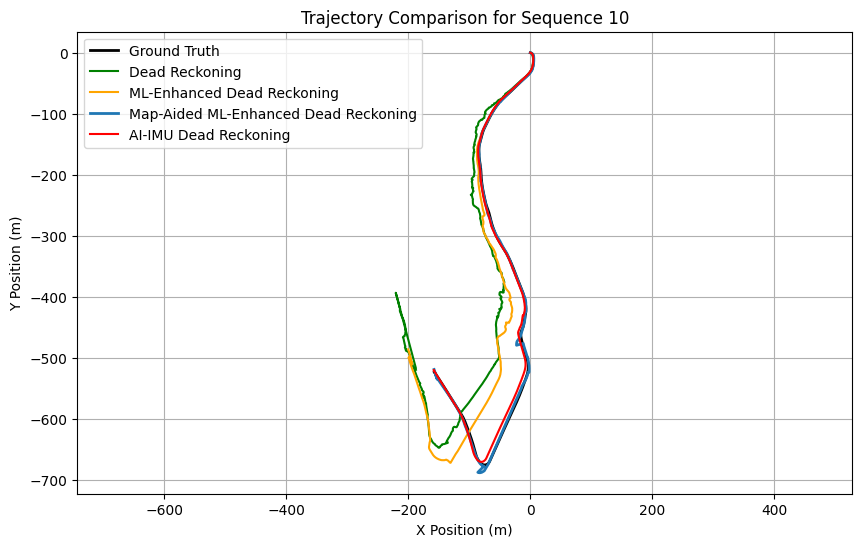

In [7]:
visualize_trajectories(
    "10",
    dead_reckoning_10,
    ml_enhanced_dead_reckoning_10,
    map_aided_ml_enhanced_dead_reckoning_10,
    ai_imu_dead_reckoning_10,
    loc="upper left",
)

### Combined plot

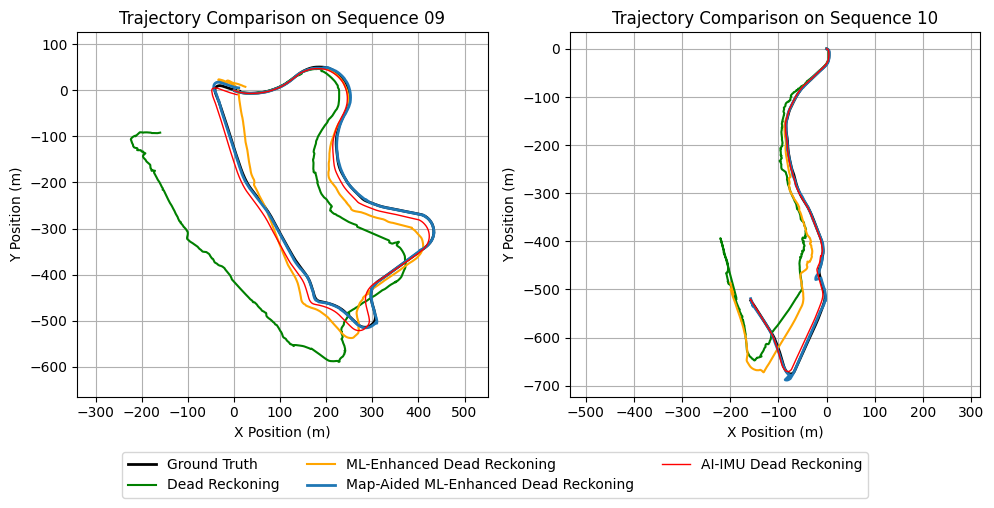

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
ground_truh_09 = map_aided_ml_enhanced_dead_reckoning_09["ground_truth_trajectory"]
dr_predicted_09 = dead_reckoning_09["estimated_trajectory"]
ml_dr_predicted_09 = ml_enhanced_dead_reckoning_09["estimated_trajectory"]
map_aided_ml_dr_predicted_09 = map_aided_ml_enhanced_dead_reckoning_09["estimated_trajectory"]
ai_imu_09 = ai_imu_dead_reckoning_09["estimated_trajectory"]

axs[0].plot(ground_truh_09[:, 0], ground_truh_09[:, 1], label="Ground Truth", color="black", linewidth=2)
axs[0].plot(dr_predicted_09[:, 0], dr_predicted_09[:, 1], label="Dead Reckoning", color="green")
axs[0].plot(ml_dr_predicted_09[:, 0], ml_dr_predicted_09[:, 1], label="ML-Enhanced Dead Reckoning", color="orange")
axs[0].plot(map_aided_ml_dr_predicted_09[:, 0], map_aided_ml_dr_predicted_09[:, 1], label="Map-Aided ML-Enhanced Dead Reckoning", lw=2)
axs[0].plot(ai_imu_09[:, 0], ai_imu_09[:, 1], label="AI-IMU Dead Reckoning", color="red", lw=1)
axs[0].set_title("Trajectory Comparison on Sequence 09")
axs[0].set_xlabel("X Position (m)")
axs[0].set_ylabel("Y Position (m)")
axs[0].axis("equal")
axs[0].grid()

ground_truh_10 = map_aided_ml_enhanced_dead_reckoning_10["ground_truth_trajectory"]
dr_predicted_10 = dead_reckoning_10["estimated_trajectory"]
ml_dr_predicted_10 = ml_enhanced_dead_reckoning_10["estimated_trajectory"]
map_aided_ml_dr_predicted_10 = map_aided_ml_enhanced_dead_reckoning_10["estimated_trajectory"]
ai_imu_10 = ai_imu_dead_reckoning_10["estimated_trajectory"]

axs[1].plot(ground_truh_10[:, 0], ground_truh_10[:, 1], label="Ground Truth", color="black", linewidth=2)
axs[1].plot(dr_predicted_10[:, 0], dr_predicted_10[:, 1], label="Dead Reckoning", color="green")
axs[1].plot(ml_dr_predicted_10[:, 0], ml_dr_predicted_10[:, 1], label="ML-Enhanced Dead Reckoning", color="orange")
axs[1].plot(map_aided_ml_dr_predicted_10[:, 0], map_aided_ml_dr_predicted_10[:, 1], label="Map-Aided ML-Enhanced Dead Reckoning", lw=2)
axs[1].plot(ai_imu_10[:, 0], ai_imu_10[:, 1], label="AI-IMU Dead Reckoning", color="red", lw=1)
axs[1].set_title("Trajectory Comparison on Sequence 10")
axs[1].set_xlabel("X Position (m)")
axs[1].set_ylabel("Y Position (m)")
axs[1].axis("equal")
axs[1].grid()

# Use one shared legend for all subplots.
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

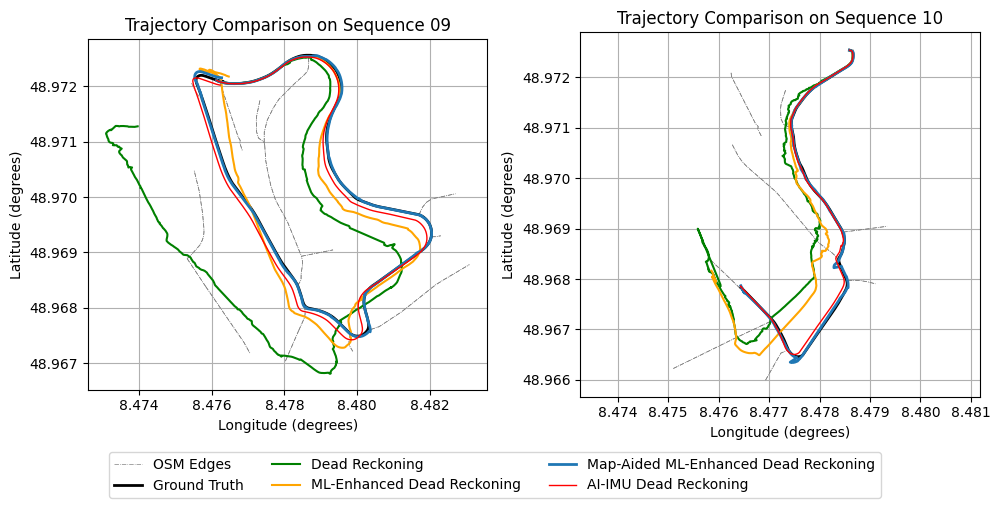

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
local_edges_09.plot(ax=axs[0], color="gray", linestyle="-.", linewidth=0.5, label="OSM Edges")
ground_truh_09 = map_aided_ml_enhanced_dead_reckoning_09["lla_ground_truth"]
dr_predicted_09 = dead_reckoning_09["lla_estimated"]
ml_dr_predicted_09 = ml_enhanced_dead_reckoning_09["lla_estimated"]
map_aided_ml_dr_predicted_09 = map_aided_ml_enhanced_dead_reckoning_09["lla_estimated"]
ai_imu_09_lla = ai_imu_dead_reckoning_09["lla_estimated"]

axs[0].plot(ground_truh_09[:, 0], ground_truh_09[:, 1], label="Ground Truth", color="black", linewidth=2)
axs[0].plot(dr_predicted_09[:, 0], dr_predicted_09[:, 1], label="Dead Reckoning", color="green")
axs[0].plot(ml_dr_predicted_09[:, 0], ml_dr_predicted_09[:, 1], label="ML-Enhanced Dead Reckoning", color="orange")
axs[0].plot(map_aided_ml_dr_predicted_09[:, 0], map_aided_ml_dr_predicted_09[:, 1], label="Map-Aided ML-Enhanced Dead Reckoning", lw=2)
axs[0].plot(ai_imu_09_lla[:, 0], ai_imu_09_lla[:, 1], label="AI-IMU Dead Reckoning", color="red", lw=1)
axs[0].set_title("Trajectory Comparison on Sequence 09")
axs[0].set_xlabel("Longitude (degrees)")
axs[0].set_ylabel("Latitude (degrees)")
axs[0].grid()

local_edges_10.plot(ax=axs[1], color="gray", linestyle="-.", linewidth=0.5, label="OSM Edges")
ground_truh_10 = map_aided_ml_enhanced_dead_reckoning_10["lla_ground_truth"]
dr_predicted_10 = dead_reckoning_10["lla_estimated"]
ml_dr_predicted_10 = ml_enhanced_dead_reckoning_10["lla_estimated"]
map_aided_ml_dr_predicted_10 = map_aided_ml_enhanced_dead_reckoning_10["lla_estimated"]
ai_imu_10_lla = ai_imu_dead_reckoning_10["lla_estimated"]

axs[1].plot(ground_truh_10[:, 0], ground_truh_10[:, 1], label="Ground Truth", color="black", linewidth=2)
axs[1].plot(dr_predicted_10[:, 0], dr_predicted_10[:, 1], label="Dead Reckoning", color="green")
axs[1].plot(ml_dr_predicted_10[:, 0], ml_dr_predicted_10[:, 1], label="ML-Enhanced Dead Reckoning", color="orange")
axs[1].plot(map_aided_ml_dr_predicted_10[:, 0], map_aided_ml_dr_predicted_10[:, 1], label="Map-Aided ML-Enhanced Dead Reckoning", lw=2)
axs[1].plot(ai_imu_10_lla[:, 0], ai_imu_10_lla[:, 1], label="AI-IMU Dead Reckoning", color="red", lw=1)
axs[1].set_title("Trajectory Comparison on Sequence 10")
axs[1].set_xlabel("Longitude (degrees)")
axs[1].set_ylabel("Latitude (degrees)")
axs[1].axis("equal")
axs[1].grid()

# Use one shared legend for all subplots.
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

## Crop point of interest

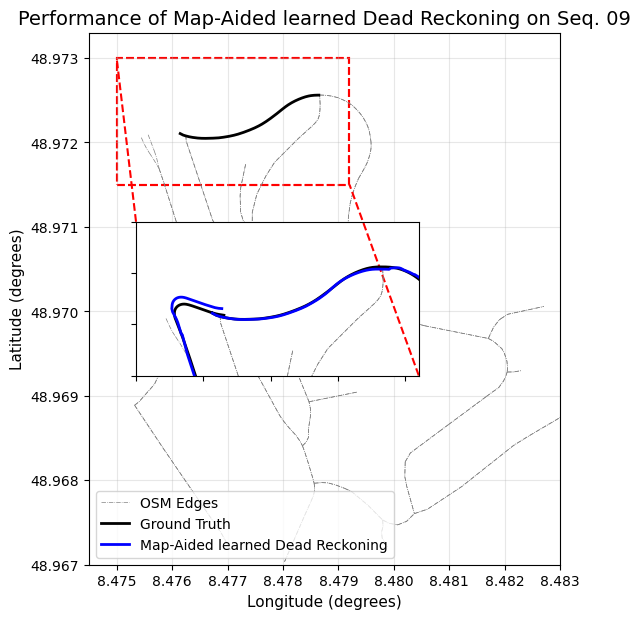

In [ ]:


fig, ax = plt.subplots(figsize=(6, 8))
local_edges_09.plot(ax=ax, color="gray", linewidth=0.5, linestyle="-.", label="OSM Edges")
# ax.plot(
#     dead_reckoning_09["lla_ground_truth"][:210, 0],
#     dead_reckoning_09["lla_ground_truth"][:210, 1],
#     label="Ground Truth",
#     color="black",
#     linewidth=2,
#     zorder=3,
#  )

# Define the crop region in geographic coordinates
x1, x2, y1, y2 = 8.475, 8.4792, 48.9715, 48.973

# Draw dashed red rectangle around the selected region on the main map
rect = Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.5, edgecolor="red", facecolor="none", linestyle="--", label="Zoom Region")
ax.add_patch(rect)

# Create inset axes for the zoomed region
axins = ax.inset_axes(
    [0.1, 0.2, 0.6, 0.6],
    xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[], zorder=3)

# Plot data in the inset
local_edges_09.plot(ax=axins, color="gray", linestyle='-.', linewidth=0.5, label="OSM Edges")
axins.plot(
    ground_truh_09[:, 0],
    ground_truh_09[:, 1],
    label="Ground Truth",
    color="black",
    linewidth=2,
    zorder=3,
 )
axins.plot(
    map_aided_ml_dr_predicted_09[:, 0],
    map_aided_ml_dr_predicted_09[:, 1],
    label="Map-Aided learned Dead Reckoning",
    lw=2,
    color="blue",
    zorder=4,
 )

# Draw connecting lines between the rectangle and the inset axes
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="red", lw=1.5, linestyle="--")
ax.set_ylim(48.967, 48.9733)
ax.set_xlim(8.4745, 8.483)
ax.set_xlabel("Longitude (degrees)", fontsize=11)
ax.set_ylabel("Latitude (degrees)", fontsize=11)
ax.set_title("Performance of Map-Aided learned Dead Reckoning on Seq. 09", fontsize=14)
ax.grid(alpha=0.3)

# Show the zoomed-region legend on the main map so it is readable in the full view.
inset_handles, inset_labels = axins.get_legend_handles_labels()
ax.legend(inset_handles, inset_labels, loc="lower left", fontsize=10)

plt.tight_layout()
plt.show()

array([[  8.476147  ,  48.97210454, 201.86813354],
       [  8.4761507 ,  48.97210321, 201.88606262],
       [  8.4761541 ,  48.97210197, 201.89958191],
       ...,
       [  8.47627411,  48.97209115, 199.09120178],
       [  8.47628467,  48.97209018, 199.11787415],
       [  8.47629434,  48.97208931, 199.14680481]], shape=(1594, 3))

## Error Aggregation

In [16]:
def _align_by_min_length(a, b):
    n = min(len(a), len(b))
    if n < 2:
        raise ValueError("At least 2 samples are required to compute trajectory metrics.")
    return a[:n], b[:n]

def compute_ATE_m(result):
    estimated_xy = np.asarray(result["estimated_trajectory"], dtype=np.float64)[:, :2]
    ground_truth_xy = np.asarray(result["ground_truth_trajectory"], dtype=np.float64)[:, :2]
    ground_truth_xy, estimated_xy = _align_by_min_length(ground_truth_xy, estimated_xy)

    errors = np.linalg.norm(ground_truth_xy - estimated_xy, axis=1)
    return float(np.sqrt(np.mean(errors ** 2)))


In [17]:
def compute_metrics_table(sequence_results):
    records = []

    for seq, methods in sequence_results.items():
        for method_name, result_data in methods.items():
            records.append(
                {
                    "sequence": seq,
                    "method": method_name,
                    "ATE_m": compute_ATE_m(result_data)
                }
            )

    metrics_df = pd.DataFrame(records)
    return metrics_df


sequence_results = {
    "09": {
        "Dead Reckoning": dead_reckoning_09,
        "ML-Enhanced Dead Reckoning": ml_enhanced_dead_reckoning_09,
        "Map-Aided ML-Enhanced Dead Reckoning": map_aided_ml_enhanced_dead_reckoning_09,
        "AI-IMU Dead Reckoning": ai_imu_dead_reckoning_09,
    },
    "10": {
        "Dead Reckoning": dead_reckoning_10,
        "ML-Enhanced Dead Reckoning": ml_enhanced_dead_reckoning_10,
        "Map-Aided ML-Enhanced Dead Reckoning": map_aided_ml_enhanced_dead_reckoning_10,
        "AI-IMU Dead Reckoning": ai_imu_dead_reckoning_10,
    },
}

metrics_df = compute_metrics_table(sequence_results)
display(metrics_df.round(4))

summary_table = metrics_df.pivot(index="sequence", columns="method", values="ATE_m")
display(summary_table.round(4))

,sequence,method,ATE_m
0,09,Dead Reckoning,111.2059
1,09,ML-Enhanced Dead Reckoning,27.7576
2,09,Map-Aided ML-Enhanced Dead Reckoning,7.2108
3,09,AI-IMU Dead Reckoning,10.5211
4,10,Dead Reckoning,55.5140
5,10,ML-Enhanced Dead Reckoning,41.3986
6,10,Map-Aided ML-Enhanced Dead Reckoning,9.4874
7,10,AI-IMU Dead Reckoning,4.6744


method,AI-IMU Dead Reckoning,Dead Reckoning,ML-Enhanced Dead Reckoning,Map-Aided ML-Enhanced Dead Reckoning
sequence,,,,
09,10.5211,111.2059,27.7576,7.2108
10,4.6744,55.5140,41.3986,9.4874


93.51563181449906

In [18]:
target_method = "Map-Aided ML-Enhanced Dead Reckoning"

def compute_percentage_update_for_target(metrics_df, target_method):
    numeric_cols = metrics_df.select_dtypes(include=[np.number]).columns.tolist()
    rows = []

    for seq, group in metrics_df.groupby("sequence"):
        values_by_method = group.set_index("method")
        if target_method not in values_by_method.index:
            continue

        for metric in numeric_cols:
            target_value = values_by_method.loc[target_method, metric]
            for method_name, method_value in values_by_method[metric].items():
                if method_name == target_method:
                    continue
                if np.isclose(method_value, 0.0):
                    pct_update = np.nan
                else:
                    # Positive means target has lower error (better) than compared method.
                    pct_update = (method_value - target_value) / method_value * 100.0

                rows.append(
                    {
                        "sequence": seq,
                        "metric": metric,
                        "compared_to": method_name,
                        "map_aided_pct_update": pct_update,
                    }
                )

    return pd.DataFrame(rows)


pct_update_df = compute_percentage_update_for_target(metrics_df, target_method)
display(pct_update_df.round(2))

pct_update_summary = pct_update_df.pivot(
    index=["sequence", "metric"],
    columns="compared_to",
    values="map_aided_pct_update",
)
display(pct_update_summary.round(2))

,sequence,metric,compared_to,map_aided_pct_update
0,09,ATE_m,Dead Reckoning,93.52
1,09,ATE_m,ML-Enhanced Dead Reckoning,74.02
2,09,ATE_m,AI-IMU Dead Reckoning,31.46
3,10,ATE_m,Dead Reckoning,82.91
4,10,ATE_m,ML-Enhanced Dead Reckoning,77.08
5,10,ATE_m,AI-IMU Dead Reckoning,-102.96


,compared_to,AI-IMU Dead Reckoning,Dead Reckoning,ML-Enhanced Dead Reckoning
sequence,metric,,,
09,ATE_m,31.46,93.52,74.02
10,ATE_m,-102.96,82.91,77.08


In [23]:
pct_update_summary.mean()

compared_to
AI-IMU Dead Reckoning        -35.748955
Dead Reckoning                88.212920
ML-Enhanced Dead Reckoning    75.552626
dtype: float64

In [24]:
(1201 - 9.4874) / 1201

0.9921004163197336